# **Task** **1** **–** **Titanic** **Dataset** **Analysis**

Objective:

 Analyze and clean the Titanic dataset and understand the factors associated with passenger survival.


In [1]:
import pandas as pd
import seaborn as sns

df = sns.load_dataset("titanic")

df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [2]:
print("Dataset Shape:" , df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape: (891, 15)

Column Names:
['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']

Data Types:
survived          int64
pclass            int64
sex              object
age             float64
sibsp             int64
parch             int64
fare            float64
embarked         object
class          category
who              object
adult_male         bool
deck           category
embark_town      object
alive            object
alone              bool
dtype: object

Missing Values:
survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64


In [3]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [7]:
df["age"] = df["age"].fillna(df["age"].median())
df["embarked"] = df["embarked"].fillna(df["embarked"].mode()[0])
print(df.isnull().sum())

survived         0
pclass           0
sex              0
age              0
sibsp            0
parch            0
fare             0
embarked         0
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64


In [8]:
# Remove deck because it has too many missing values
df = df.drop(columns=["deck"])

# Fill missing embark_town values
df["embark_town"] = df["embark_town"].fillna(df["embark_town"].mode()[0])

# Check missing values again
print(df.isnull().sum())

survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    0
alive          0
alone          0
dtype: int64


In [9]:
survival_by_gender = df.groupby("sex")["survived"].mean()

print(survival_by_gender)

sex
female    0.742038
male      0.188908
Name: survived, dtype: float64


In [13]:
survival_by_class = df.groupby("pclass")["survived"].mean()

print(survival_by_class)

pclass
1    0.629630
2    0.472826
3    0.242363
Name: survived, dtype: float64


In [16]:
age_survival = df.groupby("survived")["age"].mean()

print(age_survival)

survived
0    30.028233
1    28.291433
Name: age, dtype: float64


# Task 2 – Titanic Dataset EDA & Visualization

## Objective
Explore the Titanic dataset using visualizations to identify patterns and relationships between passenger characteristics and survival.

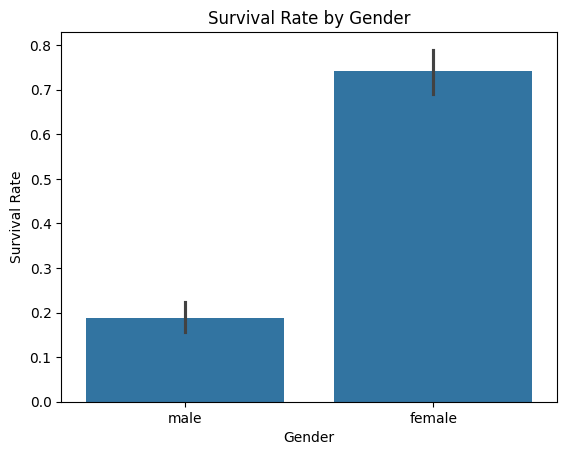

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.barplot(x="sex", y="survived", data=df)
plt.title("Survival Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Survival Rate")
plt.show()

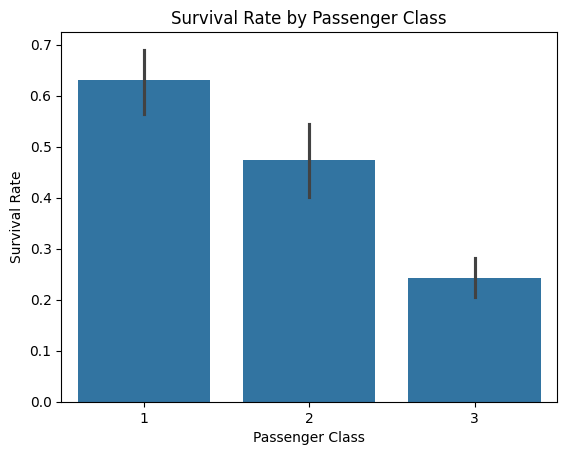

In [18]:
sns.barplot(x="pclass", y="survived", data=df)
plt.title("Survival Rate by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate")
plt.show()

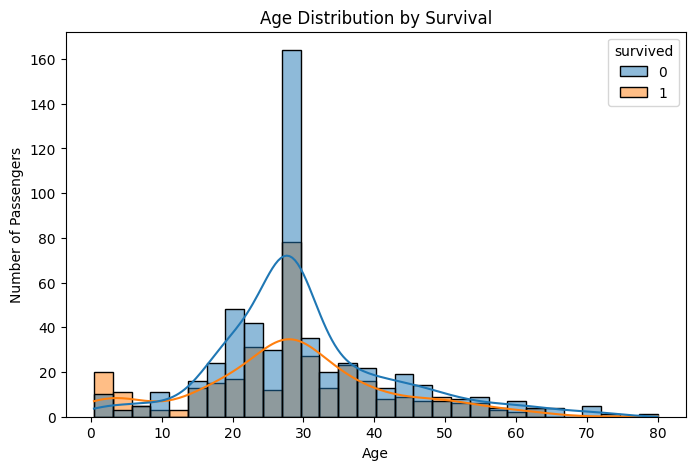

In [19]:
plt.figure(figsize=(8, 5))

sns.histplot(data=df, x="age", hue="survived", bins=30, kde=True)

plt.title("Age Distribution by Survival")
plt.xlabel("Age")
plt.ylabel("Number of Passengers")
plt.show()

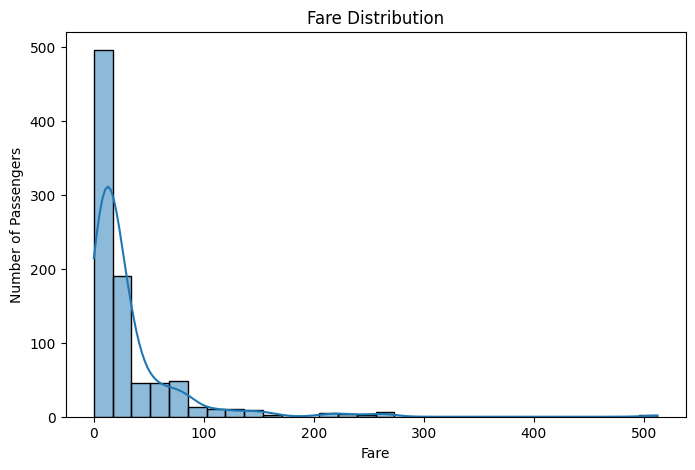

In [20]:
plt.figure(figsize=(8, 5))

sns.histplot(data=df, x="fare", bins=30, kde=True)

plt.title("Fare Distribution")
plt.xlabel("Fare")
plt.ylabel("Number of Passengers")
plt.show()

CodeAlpha Data Analytics Internship – Titanic Dataset Analysis

# **Key Findings**

• Female passengers had a higher survival rate than male passengers.

• First-class passengers had the highest survival rate.

• Third-class passengers had the lowest survival rate.

• Survivors had a slightly lower average age than non-survivors.

• Most passenger fares were concentrated in the lower fare range.

# **Conclusion**


The analysis shows that passenger gender and class were strongly associated with survival in the Titanic dataset. Female passengers and first-class passengers had considerably higher survival rates. The analysis also showed that passenger ages and fares had varied distributions. Overall, EDA and visualization helped identify important patterns and understand the factors related to passenger survival.